# Notebook 3: Modelo generativo 1 - Ruido ("muy tonto")

Primer modelo generativo, el método de referencia obligatorio del taller:
$\hat{x} = x + \text{ruido}$.

Actúa sobre los tres componentes de la descomposición factorial (Notebook
2): factor de mercado, factores sectoriales, componentes idiosincráticos.
Cada componente recibe ruido gaussiano independiente, escalado según su
propia volatilidad histórica. Después se reconstruyen los retornos
sintéticos de los 30 activos sumando los tres componentes perturbados con
las betas reales (`reconstruct_returns`, ya usado en el Notebook 2 para la
comprobación de consistencia).

Este notebook sirve de plantilla para los siguientes, todos seguirán la misma estructura: generar componentes
sintéticos, reconstruir retornos, comparar con los reales.

**Por qué actuar sobre los componentes y no sobre los retornos en bruto:**
el enunciado del taller pide un modelo simple que "coja datos originales y
les añada ruido". La forma más literal sería sumar ruido directamente a
los retornos de los 30 activos, sin pasar por ninguna descomposición.
Se descartó esa opción deliberadamente: el objetivo del proyecto no es
solo generar datos parecidos a los reales, sino poder simular después
escenarios condicionados ("más volatilidad en banca", "shock en un activo
concreto"), y eso únicamente es posible si el ruido se aplica sobre las
piezas ya separadas (mercado / sector / idiosincrático), perturbar los
retornos en bruto no daría ninguna palanca para dirigir el efecto a un
sector o activo en particular. Por eso, incluso el modelo más simple del
taller sigue esta estructura por componentes: no es una complicación
gratuita, es la base que hace posible el resto del proyecto (Notebook 2 en
adelante), y mantiene la misma interfaz que usarán los modelos más
sofisticados.

In [33]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.factors.decomposition import reconstruct_returns
from src.generators.noise import add_gaussian_noise, generate_synthetic_components_noise

## 1. Cargar los componentes reales (Notebook 2)

In [34]:
returns_real = pd.read_parquet("../data/processed/returns_daily.parquet")
market_factor = pd.read_parquet("../data/processed/market_factor.parquet")["market_factor"]
sector_factors = pd.read_parquet("../data/processed/sector_factors.parquet")
idiosyncratic = pd.read_parquet("../data/processed/idiosyncratic_returns.parquet")
betas = pd.read_parquet("../data/processed/factor_betas.parquet")

print(f"Retornos reales: {returns_real.shape}")
print(f"Factor de mercado: {market_factor.shape}")
print(f"Factores sectoriales: {sector_factors.shape}")
print(f"Componentes idiosincráticos: {idiosyncratic.shape}")

Retornos reales: (2785, 30)
Factor de mercado: (2785,)
Factores sectoriales: (2785, 30)
Componentes idiosincráticos: (2785, 30)


## 2. Generar componentes sintéticos con ruido

**Elección de `noise_std_ratio`:** con ruido aditivo independiente, la
varianza del resultado es siempre `Var(real) + Var(ruido)`. Si
`noise_std_ratio=1.0` (ruido con la misma desviación que la serie
original), la desviación del sintético queda en
$\sqrt{1^2+1^2}=\sqrt{2}\approx 1.41$ veces la real, una primera prueba
con ese valor lo confirmó exactamente: todos los activos salieron con
`std_ratio` entre 1.41 y 1.45, un ~41% de exceso sistemático de
volatilidad, y una diferencia media de correlación real-sintético de 0.042
(máxima 0.223).

Una segunda prueba con `ratio=0.2` redujo el exceso esperado de
volatilidad a $\sqrt{1+0.2^2}-1\approx 2\%$, con una diferencia de
correlación de solo 0.0053. Sin embargo, con tan poco ruido el sintético es
prácticamente una copia de los datos reales, no es un baseline
particularmente informativo, porque cualquier modelo pierde poco frente a
"casi los datos reales sin tocar".

**Se fija `noise_std_ratio=0.5` como valor final**, tras comparar 3
candidatos (0.2, 0.5, 0.8, ver tabla en la sección 5). Con `ratio=0.5` el
exceso de volatilidad esperado es de ~12%, un punto intermedio razonable:
suficiente perturbación para que el baseline sea informativo y
"financieramente razonable" (ni una copia casi exacta como 0.2, ni una
distorsión exagerada como 0.8 o 1.0).

In [35]:
NOISE_STD_RATIO = 0.5
SEED = 42

synthetic_components = generate_synthetic_components_noise(
    market_factor, sector_factors, idiosyncratic,
    noise_std_ratio=NOISE_STD_RATIO, seed=SEED,
)

market_factor_synth = synthetic_components["market_factor"]
sector_factors_synth = synthetic_components["sector_factors"]
idiosyncratic_synth = synthetic_components["idiosyncratic"]

## 3. Reconstruir retornos sintéticos

Se reutilizan las betas REALES (estimadas en el Notebook 2): el modelo de
ruido no aprende ninguna relación entre activos, solo perturba los
componentes ya descompuestos. La estructura de exposición a mercado/sector
de cada activo se mantiene igual que en los datos reales.

In [36]:
returns_synthetic = reconstruct_returns(
    market_factor_synth, sector_factors_synth, idiosyncratic_synth, betas
)
returns_synthetic.head()

,AAL,AAPL,AMD,AMZN,B,BAC,BMY,C,CLF,CSX,...,NEE,NVDA,OXY,PCG,PFE,RIG,TSLA,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,0.017617,-0.030197,0.005835,-0.008129,-0.010372,-0.035972,-0.016003,-0.030276,-0.094009,-0.022537,...,-0.002093,-0.019739,-0.027109,0.004915,0.001753,-0.053415,-0.041165,-0.024080,-0.000250,-0.027041
2015-01-06,-0.019073,-0.009989,-0.007967,-0.036629,0.021995,-0.030293,0.000545,-0.044827,-0.037968,-0.054040,...,0.010051,-0.040113,-0.003406,0.002684,0.003911,-0.033317,-0.003423,-0.036934,0.004891,-0.008339
2015-01-07,0.004751,0.031829,-0.018977,0.022112,0.002979,0.012774,0.016338,0.007862,0.093011,0.013971,...,0.017636,-0.007949,-0.004720,0.009448,0.019500,-0.027330,0.000092,0.018927,0.026519,0.009723
2015-01-08,0.023976,0.033495,0.001952,0.015981,-0.032333,0.030360,0.041706,0.020665,0.075163,0.019023,...,0.010743,0.046550,0.023006,0.029059,0.039406,0.025860,-0.007247,0.035530,0.023726,0.014783
2015-01-09,-0.059779,-0.012173,-0.009618,-0.008726,0.024566,-0.020521,-0.002022,-0.035692,-0.039430,-0.015961,...,-0.025829,0.001409,-0.033151,-0.009028,0.006189,-0.031243,-0.034081,-0.034849,-0.023981,-0.011454


## 4. Comparación real vs. sintético

Un buen generador debería producir retornos sintéticos con estadísticos
descriptivos (media, desviación estándar) parecidos a los reales, y sobre
todo una estructura de correlación entre activos similar. El modelo de
ruido, al perturbar cada componente de forma independiente, es esperable
que distorsione algo la estructura de correlación, es precisamente lo que
los modelos más sofisticados (VAE, AR/GRU) deberían mejorar.

In [37]:
comparison_stats = pd.DataFrame({
    "mean_real": returns_real.mean(),
    "mean_synth": returns_synthetic.mean(),
    "std_real": returns_real.std(),
    "std_synth": returns_synthetic.std(),
})
comparison_stats["std_ratio"] = comparison_stats["std_synth"] / comparison_stats["std_real"]
comparison_stats.sort_values("std_ratio", ascending=False)

,mean_real,mean_synth,std_real,std_synth,std_ratio
NVDA,0.002147,0.002342,0.030385,0.034555,1.137259
CLF,0.000261,-0.000326,0.043694,0.049513,1.133174
MO,0.000339,0.000084,0.014140,0.016006,1.131965
F,0.000173,0.000080,0.022442,0.025403,1.131914
WFC,0.000292,0.000003,0.019661,0.022157,1.126943
XOM,0.000320,0.000328,0.017289,0.019474,1.126394
B,0.000589,0.000292,0.024960,0.028108,1.126128
C,0.000378,0.000032,0.020647,0.023216,1.124408
AAPL,0.000851,0.000661,0.018121,0.020360,1.123522
AAL,-0.000483,-0.000778,0.031833,0.035740,1.122719


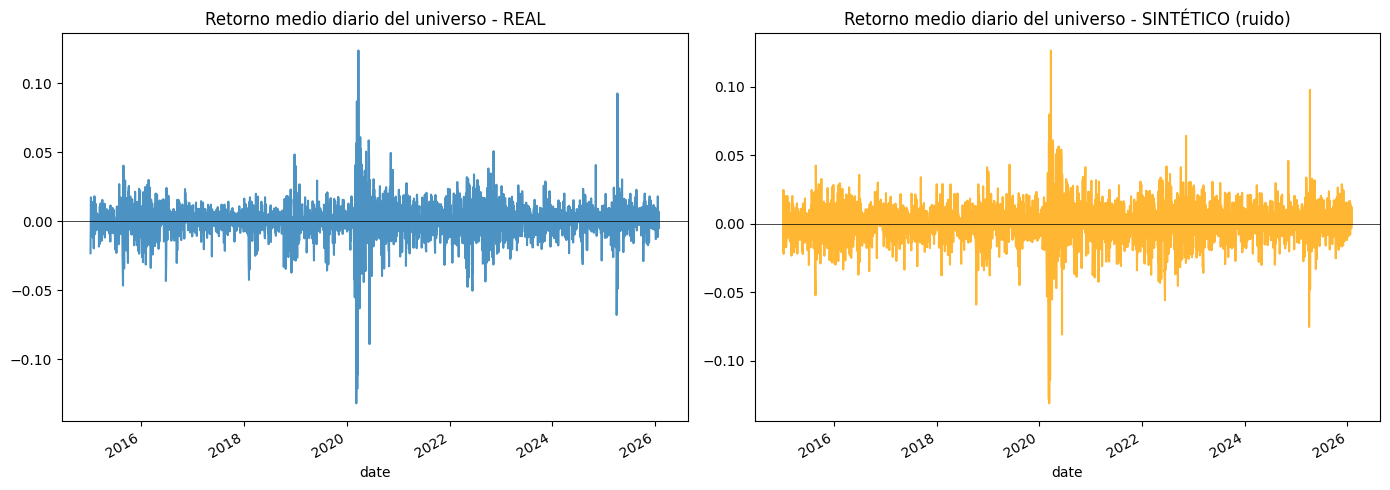

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

returns_real.mean(axis=1).plot(ax=axes[0], title="Retorno medio diario del universo - REAL", alpha=0.8)
axes[0].axhline(0, color="black", linewidth=0.5)

returns_synthetic.mean(axis=1).plot(ax=axes[1], title="Retorno medio diario del universo - SINTÉTICO (ruido)", alpha=0.8, color="orange")
axes[1].axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

**Lectura:** con `noise_std_ratio=0.5`, el sintético tiene un exceso de
volatilidad moderado sobre el real (esperado ~12%, según
$\sqrt{1+0.5^2}-1$), consistente en todos los activos. Las medias también
se mantienen razonablemente cercanas (el ruido gaussiano de media cero no
sesga la media a largo plazo; la diferencia observada es ruido de
muestra).

## 5. Comparación de la matriz de correlaciones

**Nota sobre el criterio de evaluación:** esta comparación de correlaciones
es un control de calidad, sirve para descartar que el generador produzca
algo financieramente absurdo, pero no es el objetivo final en sí mismo.
No se busca que el sintético reproduzca la correlación real casi a la
perfección; el criterio de verdad es si añadir estos datos sintéticos
mejora el predictor de la matriz de covarianzas frente a usar solo datos
reales (Notebook 8). Una diferencia de correlación moderada es aceptable
si el dato sintético sigue siendo razonable y aporta variedad útil.

In [39]:
corr_real = returns_real.corr()
corr_synth = returns_synthetic.corr()

corr_diff = (corr_real - corr_synth).abs()

print(f"Diferencia media absoluta entre correlaciones real y sintética: {corr_diff.values[np.triu_indices_from(corr_diff.values, k=1)].mean():.4f}")
print(f"Diferencia máxima: {corr_diff.values[np.triu_indices_from(corr_diff.values, k=1)].max():.4f}")

Diferencia media absoluta entre correlaciones real y sintética: 0.0189
Diferencia máxima: 0.0891


**Lectura:** con `ratio=0.5`, la diferencia media de correlación es 0.0189
(máxima 0.0891). Comparativa de los 3 valores probados:

| `noise_std_ratio` | Exceso volatilidad esperado | Diferencia media correlación | Diferencia máxima |
|---|---|---|---|
| 0.2 | ~2% | 0.0053 | 0.0214 |
| **0.5 (elegido)** | **~12%** | **0.0189** | **0.0891** |
| 0.8 | ~28% | 0.0339 | 0.1742 |

Se eligió 0.5 como punto de equilibrio: suficiente ruido para que el
baseline no sea "casi los datos reales sin tocar" (como pasaba con 0.2),
sin llegar a una distorsión excesiva (como con 0.8). Siguiendo el criterio
de la sección 5, este número (0.0189) no se usa como un umbral a batir de
forma estricta por los siguientes modelos, sirve como referencia de
contexto, y la comparación decisiva se hará en el Notebook 8 con el
predictor de covarianzas.

## 6. Guardado del dataset sintético

Se guarda con un sufijo `_noise` para poder distinguirlo de los datasets
que generen los siguientes modelos (gaussiana, VAE, AR/GRU) y poder
mezclarlos con los reales en distintas proporciones (Notebook 7).

In [40]:
returns_synthetic.to_parquet("../data/processed/returns_synthetic_noise.parquet")
print("Guardado en data/processed/returns_synthetic_noise.parquet")

Guardado en data/processed/returns_synthetic_noise.parquet


### 7. Conclusión

Se implementó el modelo de referencia obligatorio del taller: ruido gaussiano
añadido a cada uno de los tres componentes factoriales. El único parámetro a
decidir fue la magnitud del ruido (`noise_std_ratio`), y ahí sí aparece un
compromiso claro: con muy poco ruido, el modelo genera prácticamente una
copia de los datos reales, heredando su estructura de correlación casi
intacta pero sin aportar apenas variación; con demasiado, la estructura
conjunta entre activos se degrada notablemente.

Se fija `noise_std_ratio=0.5` como valor final, el punto donde el baseline
sigue siendo financieramente razonable sin ser una copia casi exacta de lo
real. Siguiendo el criterio acordado, esta diferencia de correlación se
trata como un control de calidad, no como el objetivo a minimizar: el
criterio decisivo será si estos datos sintéticos mejoran el predictor de la
matriz de covarianzas frente a usar solo datos reales.

**Siguiente paso:** modelo generativo 2 - Gaussiana ajustada (Notebook 4).